In [37]:
!pip install matplotlib
!pip install sympy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [38]:
# L'alumne escriu aquí la seva equació com a text (pot fer servir ^ per a les potències)
equacio_alumne = "0.15 * abs(x)^3 - 0.8 * x^2 + 1"
#equacio_alumne = "x^2"
#equacio_alumne = "x"


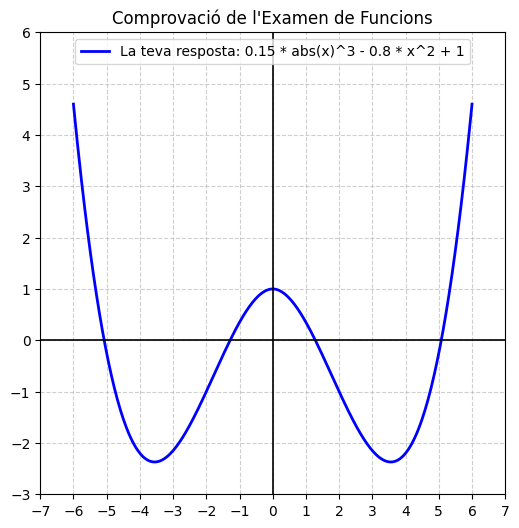

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

try:
    # 1. SymPy tradueix el text de l'alumne a matemàtiques reals
    x_sym = sp.symbols('x')
    # Canviem ^ per ** perquè SymPy no tingui problemes amb les potències
    expressio_neta = equacio_alumne.replace('^', '**')
    expressio = sp.parse_expr(expressio_neta) 
    
    # 2. Convertim l'equació matemàtica a una funció compatible amb NumPy
    f_num = sp.lambdify(x_sym, expressio, 'numpy')
    
    # 3. Generem els valors de x i y per al gràfic (Domini de -6 a 6)
    x_val = np.linspace(-6, 6, 400)
    y_val = f_num(x_val)
    
    # Si la funció dona un número fix (funció constant), omplim la llista de punts
    if isinstance(y_val, (int, float)):
        y_val = np.full_like(x_val, y_val)
        
    # 4. Dibuixem la gràfica amb l'estil de l'examen
    plt.figure(figsize=(6, 6))
    plt.plot(x_val, y_val, color='blue', linewidth=2, label=f"La teva resposta: {equacio_alumne}")
    
    # Eixos de coordenades centrals
    plt.axhline(0, color='black', linewidth=1.2)
    plt.axvline(0, color='black', linewidth=1.2)
    
    # Quadrícula i límits fixos idèntics al full de l'examen
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.xlim(-7, 7)
    plt.ylim(-3, 6)
    plt.xticks(np.arange(-7, 8, 1))
    plt.yticks(np.arange(-3, 7, 1))
    plt.legend(loc="upper center")
    plt.title("Comprovació de l'Examen de Funcions")
    plt.show()
    
except Exception as e:
    print("\n❌ Error en llegir la variable 'equacio_alumne'.")
    print("Revisa que estigui ben escrita entre cometes a la cel·la anterior.")
